These codes are adapted from **An Introduction to Statistical Learning with Applications in Python** (pp. 273 - 280)
https://www.statlearning.com/

In [ ]:
# Loading libraries
import pandas as pd # Libraries for processing data
import numpy as np

from matplotlib.pyplot import subplots # Libraries for plotting graphs

from sklearn.preprocessing import StandardScaler # Libraries for implementing ladge, lasso regression and elasticnet
from sklearn.pipeline import Pipeline
import sklearn.linear_model as skl
import sklearn.model_selection as skm

#### 📝 Our goal: Identifying important features for predicting a player's salary!

## 1. Data preparation

In [ ]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Loading data
hitter = pd.read_csv('/content/gdrive/MyDrive/dataset/Hitters.csv')

In [ ]:
hitter.head() # head(): show the upper 5 rows of the dataset

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
# Checking missing data
rows_with_nan = hitter[hitter.isnull().any(axis=1)]
print(rows_with_nan)

     AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  CHits  CHmRun  \
0      293    66      1    30   29     14      1     293     66       1   
15     183    39      3    20   15     11      3     201     42       3   
18     407   104      6    57   43     65     12    5233   1478     100   
22      22    10      1     4    2      1      6      84     26       2   
30     313    84      9    42   30     39     17    6890   1833     224   
32     517   141     27    70   87     52      9    3571    994     215   
36     161    36      0    19   10     17      4    1053    244       3   
38     346    98      5    31   53     30     16    5913   1615     235   
39     241    61      1    34   12     14      1     241     61       1   
41     216    54      0    21   18     15     18    7318   1926      46   
42     200    57      6    23   14     14      9    2516    684      46   
44     194    40      7    19   29     30     11    4183   1069      64   
48     542   140     12  

In [ ]:
# Dropping missing data
hitter.dropna(inplace=True)
hitter.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [ ]:
# Separating predictors (features) and outcome data

# Predictors
X = hitter[['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors']]

# Outcome
y = hitter['Salary']

In [ ]:
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25


In [ ]:
y.head()

,Salary
1,475.0
2,480.0
3,500.0
4,91.5
5,750.0


## 2. Regularized linear regression models: Ridge, Lasso, ElasticNet

In [ ]:
# Configuring tran-test split

# 1. Outer validation (for estimating test error): simple validation
outer_valid = skm.ShuffleSplit(n_splits = 1, # number of splitting
                               test_size = 0.25, # the proportion of the dataset to include in the test split
                               random_state = 123)

# 2. Inner validation (for identifying optimal lambda value): k-fold cross-validation
K = 10
inner_valid = skm.KFold(K, # number of folds
                        random_state = 123,
                        shuffle=True) # whether to suffle the data before splitting

### 1. Ridge regression

In [ ]:
lambdas = 10 ** np.linspace(8, -2, 100) # generating 100 numbers in the range from 10^-2 to 10^8 with equally spaced intervals

In [ ]:
# Standardizing data
scaler = StandardScaler(with_mean = True, # if True, center the data before scaling
                        with_std = True) # if Ture, scale the data ot unit variance

# Configuring model
ridgeCV = skl.ElasticNetCV(alphas=lambdas, # list of alphas
                           # n_alphas = 100, # number of alphas
                           l1_ratio=0, # 0 = ridge, 1 = lasso, 0 < ratio < 1 = elasticnet
                           max_iter = 10000, # maxinum number of iterations
                           cv=inner_valid) # determine the cross-validation spliting strategy

ridgePipe = Pipeline(steps = [('scaler', scaler), ('ridge', ridgeCV)]) # scaler is only applied to X, not y

In [ ]:
# Fitting model with our data
ridge_res = skm.cross_validate(ridgePipe,
                               X,
                               y,
                               cv=outer_valid,
                               scoring='neg_mean_squared_error',
                               return_estimator=True)

# Fitted model
ridge_model = ridge_res['estimator'][0].named_steps['ridge']

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18870022.19297194, tolerance: 3774.0045564513484
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did

In [ ]:
print('Estimated test error (MSE):', -ridge_res['test_score'][0])

Estimated test error (MSE): 125625.5393643403


In [ ]:
print('Selected lambda value:', ridge_model.alpha_)

Selected lambda value: 0.03199267137797385


In [ ]:
# Coefficient values of the model with the selected lambda
ridge_coeff = pd.DataFrame({'ridge_coeff': ridge_model.coef_}, index=X.columns)
ridge_coeff.index.name = 'feature'
ridge_coeff

,ridge_coeff
feature,
AtBat,-102.206169
Hits,56.255996
HmRun,-60.529380
Runs,22.528094
RBI,43.901893
Walks,95.346159
Years,-120.731050
CAtBat,-33.053084
CHits,138.180765


In [ ]:
# Retrieving sigma values from scaler
scaler = ridge_res['estimator'][0].named_steps['scaler']
sigma = scaler.scale_

# Unstandardizing coefficients
ridge_coeff_ori = ridge_model.coef_ / sigma

ridge_coeff_ori = pd.DataFrame({'ridge_coeff': ridge_coeff_ori}, index=X.columns)
ridge_coeff_ori.index.name = 'feature'
ridge_coeff_ori

,ridge_coeff
feature,
AtBat,-0.698932
Hits,1.288870
HmRun,-7.126838
Runs,0.903000
RBI,1.710051
Walks,4.300914
Years,-26.122123
CAtBat,-0.015337
CHits,0.228736


### 2. Lasso regression

In [ ]:
lambdas = 10 ** np.linspace(8, -2, 100) # generating 100 numbers in the range from 10^-2 to 10^8 with equally spaced intervals

In [ ]:
# Standardizing data
scaler = StandardScaler(with_mean = True , with_std = True)

# Configuring model
lassoCV = skl.ElasticNetCV(alphas=lambdas,
                           l1_ratio=1,
                           max_iter = 10000,
                           cv=inner_valid)

lassoPipe = Pipeline(steps =[('scaler', scaler), ('lasso', lassoCV)])

In [ ]:
# Fitting model with our data
lasso_res = skm.cross_validate(lassoPipe,
                               X,
                               y,
                               cv=outer_valid,
                               scoring='neg_mean_squared_error',
                               return_estimator=True)

# Fitted model
lasso_model = lasso_res['estimator'][0].named_steps['lasso']

In [ ]:
print('Estimated test error (MSE):', -lasso_res['test_score'][0])

Estimated test error (MSE): 133109.06766547196


In [ ]:
print('Selected lambda value:', lasso_model.alpha_)

Selected lambda value: 5.336699231206313


In [ ]:
# Coefficient values of the model with the selected lambda
lasso_coeff = pd.DataFrame({'lasso_coeff': lasso_model.coef_}, index=X.columns)
lasso_coeff.index.name = 'feature'
lasso_coeff

,lasso_coeff
feature,
AtBat,-0.000000
Hits,4.966630
HmRun,-27.063769
Runs,0.000000
RBI,0.000000
Walks,83.281964
Years,-118.156582
CAtBat,-0.000000
CHits,0.000000


In [ ]:
# Retrieving sigma values from scaler
scaler = lasso_res['estimator'][0].named_steps['scaler']
sigma = scaler.scale_

# Unstandardizing coefficients
lasso_coeff_ori = lasso_model.coef_ / sigma

lasso_coeff_ori = pd.DataFrame({'lasso_coeff': lasso_coeff_ori}, index=X.columns)
lasso_coeff_ori.index.name = 'feature'
lasso_coeff_ori

,lasso_coeff
feature,
AtBat,-0.000000
Hits,0.113790
HmRun,-3.186537
Runs,0.000000
RBI,0.000000
Walks,3.756717
Years,-25.565095
CAtBat,-0.000000
CHits,0.000000


### 3. ElasticNet

In [ ]:
l1_ratios = np.linspace(0, 1, 11) # generating 11 numbers in the range from 0 to 1 with equallity spaced intervals
lambdas = 10 ** np.linspace(8, -2, 100) # generating 100 numbers in the range from 10^-2 to 10^8 with equally spaced intervals

In [ ]:
# Standardizing data
scaler = StandardScaler(with_mean = True , with_std = True)

# Configuring model
elasticCV = skl.ElasticNetCV(alphas=lambdas,
                             # n_alphas = 100,
                             l1_ratio=l1_ratios,
                             max_iter=10000,
                             cv=inner_valid)

elasticPipe = Pipeline(steps =[('scaler', scaler), ('elastic', elasticCV)])

In [ ]:
# Fitting model with our data
elastic_res = skm.cross_validate(elasticPipe,
                                 X,
                                 y,
                                 cv=outer_valid,
                                 scoring='neg_mean_squared_error',
                                 return_estimator=True)

# Fitted model
elastic_model = elastic_res['estimator'][0].named_steps['elastic']

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18870022.19297194, tolerance: 3774.0045564513484
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did

In [ ]:
print('Estimated test error (MSE):', -elastic_res['test_score'][0])

Estimated test error (MSE): 125625.5393643403


In [ ]:
print('Selected lambda value:', elastic_model.alpha_)

Selected lambda value: 0.03199267137797385


In [ ]:
print('Selected l1 ratio value:', elastic_model.l1_ratio_)

Selected l1 ratio value: 0.0


In [ ]:
# Coefficient values of the model with the selected lambda
elastic_coeff = pd.DataFrame({'elastic_coeff': elastic_model.coef_}, index=X.columns)
elastic_coeff.index.name = 'feature'
elastic_coeff

,elastic_coeff
feature,
AtBat,-102.206169
Hits,56.255996
HmRun,-60.529380
Runs,22.528094
RBI,43.901893
Walks,95.346159
Years,-120.731050
CAtBat,-33.053084
CHits,138.180765


In [ ]:
# Retrieving sigma values from scaler
scaler = elastic_res['estimator'][0].named_steps['scaler']
sigma = scaler.scale_

# Unstandardizing coefficients
elastic_coeff_ori = elastic_model.coef_ / sigma

elastic_coeff_ori = pd.DataFrame({'elastic_coeff': elastic_coeff_ori}, index=X.columns)
elastic_coeff_ori.index.name = 'feature'
elastic_coeff_ori

,elastic_coeff
feature,
AtBat,-0.698932
Hits,1.288870
HmRun,-7.126838
Runs,0.903000
RBI,1.710051
Walks,4.300914
Years,-26.122123
CAtBat,-0.015337
CHits,0.228736


### 4. Simple regression

In [ ]:
# Standardizing data
scaler = StandardScaler(with_mean = True , with_std = True)

# Configuring model
simple = skl.LinearRegression()

simplePipe = Pipeline(steps =[('scaler', scaler), ('simple', simple)])

In [ ]:
# Fitting model with our data
simple_res = skm.cross_validate(simplePipe,
                                X,
                                y,
                                cv=outer_valid,
                                scoring='neg_mean_squared_error',
                                return_estimator=True)

# Fitted model
simple_model = simple_res['estimator'][0].named_steps['simple']

In [ ]:
print('Estimated test error (MSE):', -simple_res['test_score'][0])

Estimated test error (MSE): 146095.63984991633


In [ ]:
# Coefficient values of the model with the selected lambda
simple_coeff = pd.DataFrame({'simple_coeff': simple_model.coef_}, index=X.columns)
simple_coeff.index.name = 'feature'
simple_coeff

,simple_coeff
feature,
AtBat,-123.914965
Hits,28.298751
HmRun,-65.903350
Runs,-0.174735
RBI,78.414719
Walks,112.564519
Years,-102.452871
CAtBat,-816.296956
CHits,878.584511


In [ ]:
# Retrieving sigma values from scaler
scaler = simple_res['estimator'][0].named_steps['scaler']
sigma = scaler.scale_

# Unstandardizing coefficients
simple_coeff_ori = simple_model.coef_ / sigma

simple_coeff_ori = pd.DataFrame({'simple_coeff': simple_coeff_ori}, index=X.columns)
simple_coeff_ori.index.name = 'feature'
simple_coeff_ori

,simple_coeff
feature,
AtBat,-0.847387
Hits,0.648347
HmRun,-7.759579
Runs,-0.007004
RBI,3.054382
Walks,5.077606
Years,-22.167342
CAtBat,-0.378778
CHits,1.454356


### 5. Comparing the results

In [ ]:
# Estimated test error of each model
testerr_df = pd.DataFrame([[-simple_res['test_score'][0], -ridge_res['test_score'][0], -lasso_res['test_score'][0], -elastic_res['test_score'][0]]], columns=['simple', 'ridge', 'lasso', 'elasticnet'], index=['estimated test error'])
testerr_df

,simple,ridge,lasso,elasticnet
estimated test error,146095.63985,125625.539364,133109.067665,125625.539364


In [ ]:
# Standardized coefficients of each model
coeff_df = pd.concat([simple_coeff, ridge_coeff, lasso_coeff, elastic_coeff], axis=1)
coeff_df

,simple_coeff,ridge_coeff,lasso_coeff,elastic_coeff
feature,,,,
AtBat,-123.914965,-102.206169,-0.000000,-102.206169
Hits,28.298751,56.255996,4.966630,56.255996
HmRun,-65.903350,-60.529380,-27.063769,-60.529380
Runs,-0.174735,22.528094,0.000000,22.528094
RBI,78.414719,43.901893,0.000000,43.901893
Walks,112.564519,95.346159,83.281964,95.346159
Years,-102.452871,-120.731050,-118.156582,-120.731050
CAtBat,-816.296956,-33.053084,-0.000000,-33.053084
CHits,878.584511,138.180765,0.000000,138.180765


In [ ]:
# Unstandardized coefficients of each model
coeff_ori_df = pd.concat([simple_coeff_ori, ridge_coeff_ori, lasso_coeff_ori, elastic_coeff_ori], axis=1)
coeff_ori_df

,simple_coeff,ridge_coeff,lasso_coeff,elastic_coeff
feature,,,,
AtBat,-0.847387,-0.698932,-0.000000,-0.698932
Hits,0.648347,1.288870,0.113790,1.288870
HmRun,-7.759579,-7.126838,-3.186537,-7.126838
Runs,-0.007004,0.903000,0.000000,0.903000
RBI,3.054382,1.710051,0.000000,1.710051
Walks,5.077606,4.300914,3.756717,4.300914
Years,-22.167342,-26.122123,-25.565095,-26.122123
CAtBat,-0.378778,-0.015337,-0.000000,-0.015337
CHits,1.454356,0.228736,0.000000,0.228736


## (Extra) Model configuration for single fitting

#### 1. ElasticNet()

In [ ]:
# Configuring model
res = skl.ElasticNet(alpha=0.5, # alpha = lambda
                     l1_ratio=0, # 0 = ridge, 1 = lasso, 0 < ratio < 1 = elasticnet
                     max_iter = 10000) # maximum number of iterations

# Fitting model
res.fit(X, y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.259e+07, tolerance: 5.332e+03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=0.5, l1_ratio=0, max_iter=10000)

In [ ]:
# Result of model fitting
res.coef_

array([-2.1852554 ,  7.72827553,  1.96744129, -1.98893615,  0.03366563,
        6.09595846, -2.12232087, -0.1804815 ,  0.08909259, -0.20111882,
        1.5949824 ,  0.78959462, -0.78671281,  0.2947799 ,  0.38255388,
       -2.82150027])

#### 2. ElasticNet.path()

In [ ]:
lambdas = 10 ** np.linspace(8, -2, 100) # generating 100 numbers in the range from 10^-2 to 10^8 with equally spaced intervals

In [ ]:
res_array = skl.ElasticNet.path(X,
                                y,
                                l1_ratio=0, # 0 = ridge, 1 = lasso, 0 < ratio < 1 = elasticnet
                                alphas=lambdas, # list of alphas
                                #n_alphas=100, # numbers of alpha
                                max_iter = 10000)[1] # maximum number of iterations

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 59287290.33669099, tolerance: 12885.7065737425
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did n

In [ ]:
res_array.shape # (number of predictors, number of lambdas)

(16, 100)

In [ ]:
res_path = pd.DataFrame(res_array.T,
                        columns=X.columns,
                        index=-np.log(lambdas)) # transform the values for visualization purpose
res_path.index.name = 'negative log(lambda)'
res_path

feature,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
negative log(lambda),,,,,,,,,,,,,,,,
-18.420681,0.002196,0.000605,0.000069,0.000310,0.000298,0.000239,0.000042,0.017227,0.004801,0.000499,0.002437,0.002283,0.001732,0.001774,0.000591,0.000042
-18.188096,0.002707,0.000747,0.000085,0.000383,0.000367,0.000295,0.000051,0.021058,0.005870,0.000611,0.002981,0.002793,0.002117,0.002192,0.000728,0.000051
-17.955512,0.003321,0.000916,0.000104,0.000470,0.000450,0.000362,0.000062,0.025562,0.007128,0.000743,0.003622,0.003395,0.002569,0.002698,0.000892,0.000063
-17.722928,0.004051,0.001119,0.000127,0.000575,0.000549,0.000442,0.000075,0.030779,0.008586,0.000898,0.004365,0.004093,0.003093,0.003306,0.001088,0.000077
-17.490343,0.004912,0.001358,0.000154,0.000698,0.000666,0.000536,0.000090,0.036716,0.010248,0.001075,0.005214,0.004892,0.003689,0.004028,0.001318,0.000093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3.674833,-1.825521,7.370633,2.115713,-2.288509,-0.227212,6.219724,8.318121,-0.199405,0.093044,-0.235064,1.596450,0.774813,-0.768080,0.299492,0.321252,-1.413024
3.907417,-1.825708,7.371544,2.118037,-2.289413,-0.227953,6.220273,8.329501,-0.199458,0.093017,-0.235289,1.596714,0.774925,-0.768177,0.299492,0.321312,-1.413487
4.140001,-1.825857,7.372267,2.119882,-2.290129,-0.228541,6.220709,8.338542,-0.199500,0.092996,-0.235468,1.596924,0.775014,-0.768254,0.299493,0.321360,-1.413855


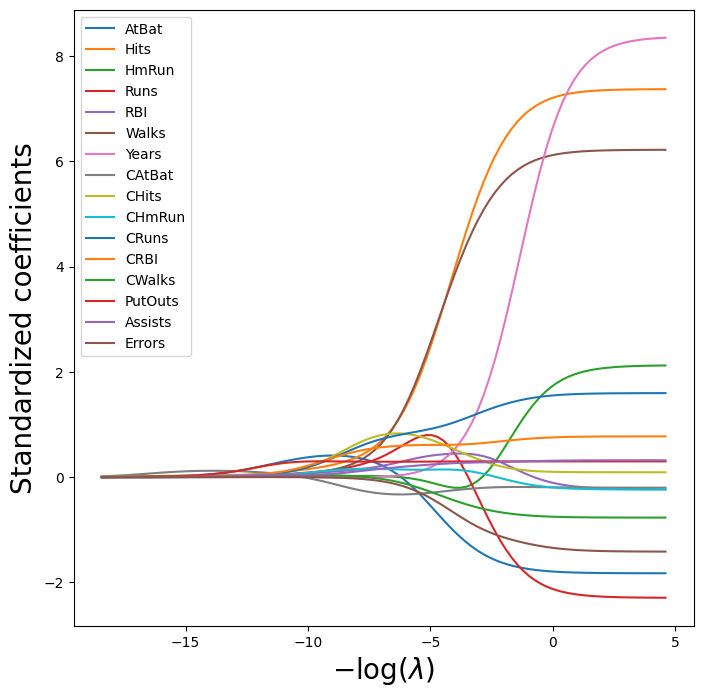

In [ ]:
path_fig, ax = subplots(figsize =(8 ,8))
res_path.plot(ax=ax, legend=False)
ax.set_xlabel('$-\log(\lambda)$', fontsize =20)
ax.set_ylabel('Standardized coefficients', fontsize =20)
ax.legend(loc='upper left');